# Phụ lục A: Bốn câu hỏi về biểu diễn đầu vào và cơ chế tinh chỉnh

Trong mạch bài chính, chúng ta đã đi từ các phép đo thống kê thủ công ([Bài 01](01_eda_and_baseline.ipynb), [Bài 02](02_features_and_lr.ipynb)) đến mạng tích chập học sâu với các chiến lược cắt ảnh khác nhau ([Bài 03](03_pretrained_and_finetune.ipynb), [Bài 04](04_native_and_resampling.ipynb)).

Phụ lục này đào sâu vào bốn câu hỏi chuyên biệt về mặt biểu diễn và kiến trúc, mỗi câu hỏi được khảo sát qua một phép đối chứng có kiểm soát chặt chẽ:
1. **Frozen Embedding kết hợp Logistic Regression:** Nếu giữ nguyên đặc trưng 1024 chiều của backbone pretrained và thay bộ phân loại bằng hồi quy logistic lồi, kết quả có tốt hơn đầu phân loại huấn luyện bằng mini-batch gradient descent không?
2. **Tinh chỉnh từng phần (Partial Fine-tuning):** Mở khóa một phần mạng có đủ để thích nghi với bài toán hay bắt buộc phải mở toàn bộ các tầng?
3. **Cơ chế gộp vùng nhìn (Pooling Strategy):** Khi có nhiều vùng cắt, việc chỉ lấy trung bình 2 logit lớn nhất (Top-2 pooling) có tốt hơn lấy trung bình toàn bộ (Mean pooling) không?
4. **Đưa trực tiếp bản đồ phần dư vào CNN:** Nếu phép loại nhóm ở bài 02 gợi ý phần dư hữu ích, liệu đưa thẳng bản đồ phần dư vào mạng ResNet-18 có vượt trội hơn ảnh màu RGB không?

Các thực nghiệm trong bài đều được thực hiện đầy đủ trên 3-fold Out-Of-Fold (800 cặp phát triển) nhằm đảm bảo tính công bằng và có thể so sánh trực tiếp.

In [1]:
from pathlib import Path
import os
import sys

def find_task_root():
    explicit = os.environ.get('KMD_PROJECT_ROOT')
    if explicit:
        root = Path(explicit).expanduser().resolve()
        if (root / 'src/kmd').is_dir():
            return root
        raise FileNotFoundError('KMD_PROJECT_ROOT phải trỏ đến thư mục KeMaoDanh chứa src/kmd.')
    cwd = Path.cwd().resolve()
    for cand in [cwd, *cwd.parents]:
        if (cand / 'src/kmd').is_dir() and (cand / 'configs').is_dir():
            return cand.resolve()
        if (cand / 'KeMaoDanh/src/kmd').is_dir() and (cand / 'KeMaoDanh/configs').is_dir():
            return (cand / 'KeMaoDanh').resolve()
    raise FileNotFoundError("Không tìm thấy thư mục gốc KeMaoDanh chứa 'src/kmd' và 'configs'.")

TASK_ROOT = find_task_root()
if str(TASK_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(TASK_ROOT / 'src'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kmd.core import PACKAGE, read_csv, split_fold, metric
from kmd.presets import get_preset_config
from kmd.pipeline import prepare_development, start_session, train_frozen_lr_cv
from kmd.suite import run_crop_comparison_suite, run_residual_suite
from kmd.teaching import resolve_data_roots, show_pair_images

KMD_SMOKE = os.environ.get('KMD_SMOKE', '0') == '1'
KMD_RUN_ID = os.environ.get('KMD_RUN_ID', 'reasoning_pilot')
RUN_ID = f"{KMD_RUN_ID}_smoke" if (KMD_SMOKE and not KMD_RUN_ID.endswith('_smoke')) else KMD_RUN_ID

data_root, test_root = resolve_data_roots(TASK_ROOT)
if not data_root.is_dir() or not (data_root / 'pairs.csv').is_file():
    raise FileNotFoundError(
        f"Không tìm thấy thư mục dữ liệu huấn luyện tại '{data_root}'. "
        "Vui lòng thiết lập biến môi trường DATA_ROOT trỏ đến thư mục chứa 'pairs.csv' và 'images/'."
    )

dev_frame = prepare_development(data_root)
session_dir = start_session(dev_frame, data_root, run_id=RUN_ID)
print(f"Thư mục dự án: {TASK_ROOT}")
print(f"Phiên làm việc: {session_dir.relative_to(PACKAGE)}")
print(f"Tổng số mẫu phát triển: {len(dev_frame)} cặp")
print(f"Chế độ chạy thử (smoke test): {KMD_SMOKE}")

Thư mục dự án: /home/purin1410-desktop/kmd_full_v5_20260920/repo/KeMaoDanh
Phiên làm việc: artifacts/models/lesson_full_v5_20260920
Tổng số mẫu phát triển: 800 cặp
Chế độ chạy thử (smoke test): False


## 1. Câu hỏi 1: Giữ nguyên embedding pretrained và thay bằng bộ phân loại logistic

Ở bài 03, nhánh `frozen` giữ nguyên toàn bộ backbone DenseNet-121 và chỉ cập nhật một lớp tuyến tính duy nhất bằng giải thuật tối ưu gradient descent (AdamW) theo từng mini-batch. Hãy đọc điểm và các lỗi của nhánh này trước khi cân nhắc thay bộ phân loại.

Một giả thuyết đặt ra: liệu sự hạn chế nằm ở chính các đặc trưng pretrained của ImageNet, hay nằm ở cách tối ưu lớp phân loại? Nếu ta trích xuất toàn bộ vector embedding 1024 chiều của mỗi ảnh rồi áp dụng một chuỗi chuẩn hóa, giảm chiều rồi hồi quy logistic thì sao?

Quy trình thực hiện trong hàm `train_frozen_lr_cv`:
1. **Tách cặp thành từng ảnh độc lập:** Với mỗi cặp ảnh trong tập huấn luyện, ảnh thứ nhất (`image_0`) nhận nhãn $1-y$, ảnh thứ hai (`image_1`) nhận nhãn $y$ (với $y=0$ thì ảnh trái mang nhãn 1 là ảnh giả; với $y=1$ thì ảnh phải mang nhãn 1).
2. **Chuẩn hóa và giảm chiều trên tập train:** Khớp `StandardScaler()` trên các vector embedding huấn luyện, tiếp tục áp dụng `PCA(n_components=min(128, dim), whiten=True)` để giảm từ 1024 chiều xuống 128 chiều có làm trắng phương sai.
3. **Huấn luyện Logistic Regression:** Khớp mô hình hồi quy logistic với tham số phạt $C=0.03$ và `fit_intercept=True`.
4. **Suy diễn xác suất cặp:** Đổi xác suất phân loại đơn lẻ của hai ảnh $q_0, q_1$ sang dạng log-odds $s_i = \log(q_i / (1 - q_i))$, sau đó xác suất cặp được tính bằng hàm sigmoid áp dụng lên hiệu số: $p = \sigma(s_1 - s_0)$.

Lưu ý phương pháp luận quan trọng:
- Số chiều PCA 128 và tham số phạt $C=0.03$ là các lựa chọn thiết kế cố định theo giao thức nghiên cứu, không phải kết quả tối ưu từ một cuộc tìm kiếm lưới siêu tham số.
- Quy trình này vừa thay đổi không gian biểu diễn (thông qua PCA làm trắng) vừa thay đổi bộ phân loại (từ tối ưu mini-batch sang hồi quy lồi L-BFGS). Đây là hai yếu tố thay đổi đồng thời (confounding factors), do đó ta chỉ có thể đánh giá toàn bộ pipeline chứ không thể quy kết quả cho riêng bộ phân loại logistic.
- Lưu ý thêm từ bài EDA: đặc trưng entropy trong bảng 32 thuộc tính là thước đo phân tán trên biểu đồ tần suất mức xám (histogram), không phải là phép đo không gian điểm ảnh.

In [2]:
print("Huấn luyện mô hình Frozen Embedding + Logistic Regression qua 3 fold OOF...")
oof_frozen_lr = train_frozen_lr_cv(
    'frozen_lr', dev_frame, data_root, session_dir, folds=(0, 1, 2), smoke=KMD_SMOKE
)

metrics_frozen_lr = metric(dev_frame.fake_position, oof_frozen_lr.p)
print("\nKết quả kiểm định 3-fold OOF của Frozen Embedding + LR (800 cặp phát triển):")
print(f"- Macro-F1:  {metrics_frozen_lr['macro_f1'] * 100:.2f}%")
print(f"- Accuracy:  {metrics_frozen_lr['accuracy'] * 100:.2f}%")
print(f"- Log Loss:  {metrics_frozen_lr['log_loss']:.4f}")
print(f"- Số lỗi:    {metrics_frozen_lr['errors']} / 800 cặp")

Huấn luyện mô hình Frozen Embedding + Logistic Regression qua 3 fold OOF...



Kết quả kiểm định 3-fold OOF của Frozen Embedding + LR (800 cặp phát triển):
- Macro-F1:  88.62%
- Accuracy:  88.62%
- Log Loss:  0.2744
- Số lỗi:    91 / 800 cặp


### Đọc kết quả của embedding giữ nguyên

So sánh trực tiếp `frozen_lr` với `frozen` trên **cùng 800 dự đoán OOF**, rồi đặt cạnh LR 32 đặc trưng và `center60`. Nếu pipeline mới tốt hơn `frozen`, ta biết cách khai thác embedding có ảnh hưởng; chưa tách được tác động của PCA, chuẩn hóa và bộ tối ưu. Nếu vẫn thua full fine-tune, đó là lý do thử cập nhật backbone. Nếu ngang hoặc hơn, chi phí thấp hơn của việc giữ nguyên backbone trở thành một lựa chọn đáng giữ lại.

Không dùng bảng fold 0 ở bài 03 để so với OOF 800 cặp. Cell dưới hoàn thành các fold còn lại và ghép dự đoán trước khi tính điểm.

In [3]:
from kmd.pipeline import complete_method_cv, aligned_predictions
comparison = []
for method in ('lr_full32', 'frozen', 'frozen_lr', 'center60'):
    pred = complete_method_cv('lr' if method == 'lr_full32' else method, dev_frame, data_root, session_dir, smoke=KMD_SMOKE)
    pred = aligned_predictions(pred, dev_frame)
    comparison.append({'method': method, **metric(dev_frame.fake_position, pred.p)})
print(pd.DataFrame(comparison).to_string(index=False))


frozen_s20260917_f1: epoch 1/24, loss=0.7048, current_F1=0.5466, best=0.5466


frozen_s20260917_f1: epoch 2/24, loss=0.6722, current_F1=0.6180, best=0.6180


frozen_s20260917_f1: epoch 3/24, loss=0.6502, current_F1=0.6844, best=0.6844


frozen_s20260917_f1: epoch 4/24, loss=0.6306, current_F1=0.7522, best=0.7522


frozen_s20260917_f1: epoch 5/24, loss=0.6145, current_F1=0.7786, best=0.7786


...

frozen_s20260917_f2: epoch 11/24, loss=0.5354, current_F1=0.7703, best=0.7741


frozen_s20260917_f2: epoch 12/24, loss=0.5285, current_F1=0.7666, best=0.7741


frozen_s20260917_f2: epoch 13/24, loss=0.5203, current_F1=0.7666, best=0.7741


frozen_s20260917_f2: epoch 14/24, loss=0.5111, current_F1=0.7664, best=0.7741


   method   n  macro_f1  accuracy      auc  log_loss  errors
lr_full32 800  0.788742   0.78875 0.875681  0.443716     169
   frozen 800  0.817499   0.81750 0.897728  0.430060     146
frozen_lr 800  0.886241   0.88625 0.955881  0.274422      91
 center60 800  0.966246   0.96625 0.992063  0.148008      27


## 2. Câu hỏi 2: Tinh chỉnh từng phần (Partial) so với Tinh chỉnh toàn bộ (Full)

Khi tài nguyên tính toán bị giới hạn, việc tinh chỉnh toàn bộ mạng nơ-ron sâu (Full fine-tune) tốn nhiều bộ nhớ và thời gian tính toán. Một phương án trung gian là tinh chỉnh từng phần (Partial fine-tune):
- Đóng băng hầu hết các tầng trích xuất phía trước của DenseNet-121.
- Chỉ mở khóa cho phép cập nhật trọng số ở khối tích chập cuối cùng (`features.denseblock4`), tầng chuẩn hóa cuối (`features.norm5`) và lớp phân loại (`classifier`).

Để đánh giá khách quan, chúng ta cần một phép thử đối chứng có kiểm soát giữa hai dạng đầu vào:
- `partial_native` so với `partial_resampled`.
- `native` so với `resampled`.

Cả 4 cấu hình đều dùng cùng kiến trúc DenseNet-121, cùng 4 vùng cắt 224x224, cùng hàm mất mát ảnh và cùng ngân sách kết thúc 19 epoch terminal.

Lưu ý phương pháp luận: Cấu hình Partial ở đây chỉ áp dụng cho đầu vào 4 vùng cắt (Native và Resampled). Không thể so sánh trực tiếp kết quả Partial này với một cấu hình vùng tâm (Center60) chưa từng được huấn luyện ở chế độ Partial, vì sự so sánh đó sẽ bị nhiễu bởi sự khác nhau về vùng nhìn.

In [4]:
print("Chạy bộ suite đối chứng vùng cắt và cơ chế tinh chỉnh qua 3 fold OOF...")
table_crops, preds_crops = run_crop_comparison_suite(
    dev_frame, data_root, session_dir, smoke=KMD_SMOKE
)

display_crop_cols = ['name', 'macro_f1', 'accuracy', 'log_loss', 'errors']
print("\nBảng kết quả đối chứng các cấu hình vùng cắt (3-fold OOF trên 800 cặp):")
print(table_crops[display_crop_cols].to_string(index=False))

Chạy bộ suite đối chứng vùng cắt và cơ chế tinh chỉnh qua 3 fold OOF...


partial_native_s20260917_f0: epoch 1/19, loss=0.7065, current_F1=0.5877, best=0.5877


partial_native_s20260917_f0: epoch 2/19, loss=0.6796, current_F1=0.7228, best=0.7228


partial_native_s20260917_f0: epoch 3/19, loss=0.6311, current_F1=0.8314, best=0.8314


partial_native_s20260917_f0: epoch 4/19, loss=0.5341, current_F1=0.8839, best=0.8839


...

top2_s20260917_f2: epoch 16/19, loss=0.0478, current_F1=0.9586, best=0.9586


top2_s20260917_f2: epoch 17/19, loss=0.0064, current_F1=0.9360, best=0.9360


top2_s20260917_f2: epoch 18/19, loss=0.0072, current_F1=0.9435, best=0.9435


top2_s20260917_f2: epoch 19/19, loss=0.0015, current_F1=0.9511, best=0.9511



Bảng kết quả đối chứng các cấu hình vùng cắt (3-fold OOF trên 800 cặp):
             name  macro_f1  accuracy  log_loss  errors
   partial_native  0.937475   0.93750  0.181492      50
partial_resampled  0.908746   0.90875  0.254385      73
           native  0.966247   0.96625  0.197899      27
        resampled  0.941243   0.94125  0.335235      47
             top2  0.956249   0.95625  0.221881      35


### Phân tích cặp đối xứng Partial và Full

Hãy đọc chênh lệch giữa Native và Resampled trên từng mức độ tinh chỉnh:

In [5]:
res_by_name = table_crops.set_index('name')

if 'partial_native' in res_by_name.index and 'partial_resampled' in res_by_name.index:
    f1_p_nat = res_by_name.loc['partial_native', 'macro_f1'] * 100.0
    f1_p_res = res_by_name.loc['partial_resampled', 'macro_f1'] * 100.0
    delta_p = f1_p_nat - f1_p_res
    err_p_nat = int(res_by_name.loc['partial_native', 'errors'])
    err_p_res = int(res_by_name.loc['partial_resampled', 'errors'])
    print(f"1. Ở cấp độ Tinh chỉnh từng phần (Partial Fine-tune):")
    print(f"   - Partial Native:    {f1_p_nat:.2f}% ({err_p_nat} lỗi)")
    print(f"   - Partial Resampled: {f1_p_res:.2f}% ({err_p_res} lỗi)")
    print(f"   - Chênh lệch (Native trừ Resampled): {delta_p:+.2f} điểm phần trăm")

if 'native' in res_by_name.index and 'resampled' in res_by_name.index:
    f1_f_nat = res_by_name.loc['native', 'macro_f1'] * 100.0
    f1_f_res = res_by_name.loc['resampled', 'macro_f1'] * 100.0
    delta_f = f1_f_nat - f1_f_res
    err_f_nat = int(res_by_name.loc['native', 'errors'])
    err_f_res = int(res_by_name.loc['resampled', 'errors'])
    print(f"\n2. Ở cấp độ Tinh chỉnh toàn bộ (Full Fine-tune):")
    print(f"   - Full Native:       {f1_f_nat:.2f}% ({err_f_nat} lỗi)")
    print(f"   - Full Resampled:    {f1_f_res:.2f}% ({err_f_res} lỗi)")
    print(f"   - Chênh lệch (Native trừ Resampled): {delta_f:+.2f} điểm phần trăm")

if 'native' in res_by_name.index and 'partial_native' in res_by_name.index:
    delta_full_gain = (res_by_name.loc['native', 'macro_f1'] - res_by_name.loc['partial_native', 'macro_f1']) * 100.0
    print(f"\n3. Mức cải thiện khi mở khóa toàn bộ trên Native (Full so với Partial): {delta_full_gain:+.2f} điểm phần trăm")

1. Ở cấp độ Tinh chỉnh từng phần (Partial Fine-tune):
   - Partial Native:    93.75% (50 lỗi)
   - Partial Resampled: 90.87% (73 lỗi)
   - Chênh lệch (Native trừ Resampled): +2.87 điểm phần trăm

2. Ở cấp độ Tinh chỉnh toàn bộ (Full Fine-tune):
   - Full Native:       96.62% (27 lỗi)
   - Full Resampled:    94.12% (47 lỗi)
   - Chênh lệch (Native trừ Resampled): +2.50 điểm phần trăm

3. Mức cải thiện khi mở khóa toàn bộ trên Native (Full so với Partial): +2.88 điểm phần trăm


## 3. Câu hỏi 3: Cơ chế gộp logit đa vùng nhìn: Mean pooling hay Top-2 pooling?

Khi một bức ảnh được cắt thành 4 vùng cục bộ, mô hình đưa ra 4 giá trị logit tương ứng $s^{(1)}, s^{(2)}, s^{(3)}, s^{(4)}$. Cơ chế mặc định là lấy trung bình cộng cả 4 logit (Mean pooling):
$$\bar{s} = \frac{1}{4} \sum_{v=1}^4 s^{(v)}$$

Tuy nhiên, nếu giả định rằng dấu vết can thiệp khuôn mặt chỉ nằm cục bộ tại một vùng nhỏ (ví dụ khóe mắt, vành tai), thì 3 vùng cắt bình thường còn lại có thể kéo trung bình logit về mức an toàn, làm suy yếu tín hiệu cảnh báo.

Từ đó xuất hiện ý tưởng **Top-2 pooling**: chỉ lấy trung bình của 2 logit có giá trị lớn nhất trong 4 vùng cắt:
$$\bar{s}_{top2} = \frac{1}{2} \left( s_{(1)} + s_{(2)} \right) \quad \text{với } s_{(1)} \geq s_{(2)} \geq s_{(3)} \geq s_{(4)}$$

Cảnh báo rủi ro về mặt phương pháp:
Trực giác này có thể dẫn tới việc **khuếch đại dương tính giả (false positive)**. Nếu một vùng cắt bình thường chứa nhiễu ngẫu nhiên hoặc tạo tác nén JPEG cục bộ khiến mạng bị đánh lừa và trả về logit cao, cơ chế Top-2 sẽ ưu tiên giữ lại giá trị cực đoan đó và phớt lờ hai vùng cắt sạch còn lại, khiến toàn bộ bức ảnh bị kết luận sai là ảnh giả.

In [6]:
if 'native' in res_by_name.index and 'top2' in res_by_name.index:
    sc_mean = res_by_name.loc['native']
    sc_top2 = res_by_name.loc['top2']
    
    comp_pooling = pd.DataFrame([
        {'Cơ chế': 'Mean pooling (Trung bình 4 vùng)', 'Macro-F1 (%)': sc_mean['macro_f1'] * 100.0, 'Errors': int(sc_mean['errors']), 'Log Loss': sc_mean['log_loss']},
        {'Cơ chế': 'Top-2 pooling (Trung bình 2 vùng cao nhất)', 'Macro-F1 (%)': sc_top2['macro_f1'] * 100.0, 'Errors': int(sc_top2['errors']), 'Log Loss': sc_top2['log_loss']}
    ])
    print("So sánh cơ chế gộp logit trên cùng đầu vào Native 4 vùng cắt:")
    print(comp_pooling.to_string(index=False))
    
    delta_pool = (sc_top2['macro_f1'] - sc_mean['macro_f1']) * 100.0
    print(f"\nChênh lệch Macro-F1 (Top-2 trừ Mean): {delta_pool:+.2f} điểm phần trăm")

So sánh cơ chế gộp logit trên cùng đầu vào Native 4 vùng cắt:
                                    Cơ chế  Macro-F1 (%)  Errors  Log Loss
          Mean pooling (Trung bình 4 vùng)     96.624742      27  0.197899
Top-2 pooling (Trung bình 2 vùng cao nhất)     95.624938      35  0.221881

Chênh lệch Macro-F1 (Top-2 trừ Mean): -1.00 điểm phần trăm


### Đọc kết quả gộp vùng

Nếu Top-2 giảm lỗi, cách ưu tiên logit lớn đáng được giữ như một ứng viên. Nếu tăng lỗi, xem các cặp mới sai và kiểm tra logit của từng vùng: có phải một vùng bất thường đã kéo dự đoán đi không? Điểm tổng hợp chỉ cho biết cách gộp nào tốt hơn trong phép thử này, chưa chứng minh vị trí hay bản chất dấu vết.

Số 2 là phương án trung gian giữa chọn một vùng cực đại và trung bình cả bốn, chưa qua tìm kiếm giá trị tối ưu. Hai nhánh được train riêng với cùng ngân sách; đây không chỉ là đổi cách gộp ở lúc suy diễn.

## 4. Câu hỏi 4: Đưa trực tiếp bản đồ phần dư vào CNN (ResNet-18)

Bài 02 cho phép kiểm tra nhóm texture có đóng góp cho LR hay không. Dù kết quả ra sao, các phép đo phần dư mới tóm tắt một ảnh thành vài số và bỏ vị trí của từng chi tiết.

Một câu hỏi tự nhiên nảy sinh: Thay vì chỉ tính trung bình hay độ lệch chuẩn của phần dư rồi nạp vào mô hình hồi quy, tại sao ta không đưa trực tiếp toàn bộ ma trận phần dư vào một mạng nơ-ron tích chập (CNN)? Mạng CNN có thể tự học các bộ lọc không gian phức tạp hơn trên chính bản đồ phần dư đó.

Chúng ta thiết lập một phép thử có kiểm soát với kiến trúc ResNet-18 trên 3 dạng đầu vào khác nhau (cùng ngân sách 19 epoch terminal):
1. `resnet18_rgb`: Ảnh màu 3 kênh chuẩn.
2. `resnet18_gaussian`: Bản đồ phần dư thu được bằng cách lấy ảnh gốc trừ đi ảnh đã làm mờ Gaussian lọc thấp tần (chuẩn hóa tính từ tập train của từng fold).
3. `resnet18_npr`: Bản đồ phần dư nội suy láng giềng gần nhất (Nearest-Neighbor Resampling residual).

Nguyên tắc phương pháp luận:
Không suy diễn từ việc một đặc trưng hữu ích trong mô hình tuyến tính đơn giản sang kết luận rằng nó chắc chắn sẽ cải thiện mạng nơ-ron sâu. Mạng CNN tự có khả năng học các bộ lọc vi phân và trích xuất biên từ ảnh màu RGB gốc; việc loại bỏ hoàn toàn các dải tần số thấp có thể làm mất đi các cấu trúc khuôn mặt quan trọng cần thiết cho việc định hướng không gian.

In [7]:
print("Huấn luyện bộ suite ResNet-18 trên các dạng biểu diễn đầu vào qua 3 fold OOF...")
table_res, preds_res = run_residual_suite(
    dev_frame, data_root, session_dir, smoke=KMD_SMOKE
)

display_res_cols = ['name', 'macro_f1', 'accuracy', 'log_loss', 'errors']
print("\nBảng kết quả đối chứng ResNet-18 theo dạng đầu vào (3-fold OOF trên 800 cặp):")
print(table_res[display_res_cols].to_string(index=False))

Huấn luyện bộ suite ResNet-18 trên các dạng biểu diễn đầu vào qua 3 fold OOF...


resnet18_rgb_s20260917_f0: epoch 1/19, loss=0.6868, current_F1=0.6328, best=0.6328


resnet18_rgb_s20260917_f0: epoch 2/19, loss=0.6594, current_F1=0.7116, best=0.7116


resnet18_rgb_s20260917_f0: epoch 3/19, loss=0.5321, current_F1=0.9363, best=0.9363


resnet18_rgb_s20260917_f0: epoch 4/19, loss=0.3664, current_F1=0.9551, best=0.9551


...

resnet18_npr_s20260917_f2: epoch 16/19, loss=0.1616, current_F1=0.9398, best=0.9398


resnet18_npr_s20260917_f2: epoch 17/19, loss=0.0797, current_F1=0.9398, best=0.9398


resnet18_npr_s20260917_f2: epoch 18/19, loss=0.0660, current_F1=0.9473, best=0.9473


resnet18_npr_s20260917_f2: epoch 19/19, loss=0.1194, current_F1=0.9285, best=0.9285



Bảng kết quả đối chứng ResNet-18 theo dạng đầu vào (3-fold OOF trên 800 cặp):
             name  macro_f1  accuracy  log_loss  errors
     resnet18_rgb  0.964996     0.965  0.133207      28
resnet18_gaussian  0.945000     0.945  0.173467      44
     resnet18_npr  0.939994     0.940  0.204391      48


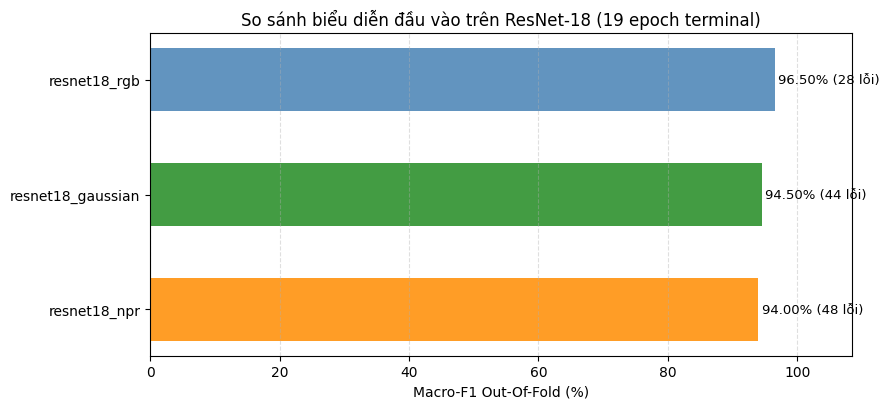

In [8]:
plt.figure(figsize=(9.0, 4.2))
res_names = table_res['name'].tolist()
res_f1 = (table_res['macro_f1'] * 100.0).tolist()
res_errs = table_res['errors'].tolist()

colors = ['steelblue', 'forestgreen', 'darkorange']
y_pos = np.arange(len(res_names))

plt.barh(y_pos, res_f1, color=colors, alpha=0.85, height=0.55)
plt.yticks(y_pos, [n.replace('_smoke', '') for n in res_names])
plt.xlabel("Macro-F1 Out-Of-Fold (%)")
plt.title(f"So sánh biểu diễn đầu vào trên ResNet-18 ({'Chế độ Smoke' if KMD_SMOKE else '19 epoch terminal'})")
plt.gca().invert_yaxis()

for idx, (val, err) in enumerate(zip(res_f1, res_errs)):
    plt.text(val + 0.5, idx, f"{val:.2f}% ({err} lỗi)", va='center', fontsize=9.5)

plt.xlim(0, max(res_f1) + 12)
plt.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Đọc ba dạng đầu vào

Nếu RGB hơn Gaussian residual, giữ RGB trong cấu hình đang xét và ghi lại mức chênh lệch. Một khả năng là phần dư đã bỏ thông tin hữu ích; khả năng khác là chuẩn hóa hoặc ngân sách hiện tại chưa phù hợp. Nếu residual hơn, cần kiểm tra các lỗi được sửa trước khi quy lợi thế cho chi tiết tần số cao. Đọc NPR theo cùng cách, kể cả khi ba nhánh gần như hòa nhau.

## 5. Từ kết quả đến quyết định tiếp theo

Với mỗi phép so sánh, ghi một dòng gồm cấu hình thay đổi, đối chứng, chênh lệch F1/số lỗi và một cặp ảnh cần xem thêm. Chỉ giữ nhận xét được bảng hiện tại hỗ trợ. Nếu một phương án không tốt hơn, ta vẫn học được điều gì đã được thử với ngân sách nào, thay vì kết luận ý tưởng đó luôn vô ích.

Ở [Phụ lục B](extension_b_objectives_and_repair.ipynb), giữ cách nhìn ảnh và chuyển sang câu hỏi khác: mạng nên học từng ảnh hay học trực tiếp thứ tự trong cặp?